In [199]:
#Librerie
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import altair as alt

In [200]:
filterwarnings("ignore")

In [201]:
#Definizione di funzioni per calcolare sse, bss e le performance di clusteirng
def get_sse(X, labels):
    sse = 0
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        sse += np.sum(cdist(np.expand_dims(c, axis=0), X[labels == l])**2)
    return sse

def get_bss(X, labels):
    cluster_centers = list()
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        cluster_centers.append(c)
    cluster_centers = np.array(cluster_centers)
    _, sizes = np.unique(labels, return_counts=True)
    m = np.mean(X, axis=0)
    bss = np.sum(sizes * cdist(np.expand_dims(m, axis=0), cluster_centers)**2)
    return bss

def eval_clustering(X, labels):
    sse = get_sse(X[labels != -1], labels[labels != -1])
    bss = get_bss(X[labels != -1], labels[labels != -1])
    silh = silhouette_score(X[labels != -1], labels[labels != -1])
    return sse, bss, silh

In [202]:
#Dataset necessari
df_sport_profile = pd.read_csv("Sport_profile_static.csv")
df_sport_year = pd.read_csv("Sport_features_by_year.csv")
df_macro_sport = pd.read_csv("Macro_sports.csv")

In [203]:
df_sport_profile

,sport,n_nations_mean,n_nations_max,athletes_per_event,pct_team_events,hhi_gold_mean,hhi_gold_athletes_mean,mean_gold_per_athletes,n_nations_with_gold,hhi_total_mean,hhi_total_athletes_mean,n_nations_with_medal,mean_total_per_athletes,n_editions
0,3x3 Basketball,13.000000,13,8.000000,1.000000,0.500000,0.500000,0.250000,2.000000,0.222222,0.209877,5.000000,0.225000,1
1,Archery,37.846154,50,38.619231,0.353846,0.648462,0.627990,0.360897,1.923077,0.242051,0.226660,6.076923,0.350373,13
2,Artistic Gymnastics,35.600000,59,74.066667,0.142857,0.275273,0.258385,0.279776,6.266667,0.215933,0.192367,10.200000,0.492368,15
3,Artistic Swimming,20.600000,24,19.250000,0.850000,0.955556,0.955556,0.332222,1.100000,0.324889,0.324637,3.200000,0.333056,10
4,Athletics,105.533333,134,37.096529,0.091415,0.140041,0.115076,0.084064,17.533333,0.101936,0.059095,32.600000,0.132437,15
5,Badminton,34.400000,50,23.390000,0.580000,0.487500,0.491405,0.152416,2.300000,0.267092,0.224149,4.900000,0.216853,10
6,Baseball,6.888889,8,6.888889,1.000000,1.000000,1.000000,0.044444,0.666667,0.333333,0.333333,2.000000,0.044444,9
7,Basketball,15.600000,18,11.633333,1.000000,0.833333,0.837037,0.070833,1.333333,0.270370,0.266240,4.133333,0.072917,15
8,Basque pelota,7.500000,8,4.425000,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,2
9,Beach Volleyball,22.857143,24,19.214286,1.000000,0.571429,0.602340,0.167857,1.857143,0.269841,0.276948,4.285714,0.229762,7


In [204]:
df_sport_profile.shape

(55, 14)

In [205]:
# Per l'analisi di clustering mantengo solo gli sport che sono stati presenti in almeno 5 edizioni olimpiche
df_sport_profile = df_sport_profile[df_sport_profile['n_editions'] >= 5]

In [206]:
df_sport_profile.shape

(39, 14)

In [207]:
df_sport_profile

,sport,n_nations_mean,n_nations_max,athletes_per_event,pct_team_events,hhi_gold_mean,hhi_gold_athletes_mean,mean_gold_per_athletes,n_nations_with_gold,hhi_total_mean,hhi_total_athletes_mean,n_nations_with_medal,mean_total_per_athletes,n_editions
1,Archery,37.846154,50,38.619231,0.353846,0.648462,0.627990,0.360897,1.923077,0.242051,0.226660,6.076923,0.350373,13
2,Artistic Gymnastics,35.600000,59,74.066667,0.142857,0.275273,0.258385,0.279776,6.266667,0.215933,0.192367,10.200000,0.492368,15
3,Artistic Swimming,20.600000,24,19.250000,0.850000,0.955556,0.955556,0.332222,1.100000,0.324889,0.324637,3.200000,0.333056,10
4,Athletics,105.533333,134,37.096529,0.091415,0.140041,0.115076,0.084064,17.533333,0.101936,0.059095,32.600000,0.132437,15
5,Badminton,34.400000,50,23.390000,0.580000,0.487500,0.491405,0.152416,2.300000,0.267092,0.224149,4.900000,0.216853,10
6,Baseball,6.888889,8,6.888889,1.000000,1.000000,1.000000,0.044444,0.666667,0.333333,0.333333,2.000000,0.044444,9
7,Basketball,15.600000,18,11.633333,1.000000,0.833333,0.837037,0.070833,1.333333,0.270370,0.266240,4.133333,0.072917,15
9,Beach Volleyball,22.857143,24,19.214286,1.000000,0.571429,0.602340,0.167857,1.857143,0.269841,0.276948,4.285714,0.229762,7
11,Boxing,66.533333,89,25.470497,0.000000,0.239113,0.212503,0.199270,6.933333,0.083427,0.067797,20.866667,0.342639,15
12,Canoe Slalom,25.555556,32,21.138889,0.222222,0.416667,0.442730,0.240346,3.111111,0.183642,0.175514,7.111111,0.301831,9


In [208]:
df_sport_profile.columns

Index(['sport', 'n_nations_mean', 'n_nations_max', 'athletes_per_event',
       'pct_team_events', 'hhi_gold_mean', 'hhi_gold_athletes_mean',
       'mean_gold_per_athletes', 'n_nations_with_gold', 'hhi_total_mean',
       'hhi_total_athletes_mean', 'n_nations_with_medal',
       'mean_total_per_athletes', 'n_editions'],
      dtype='object')

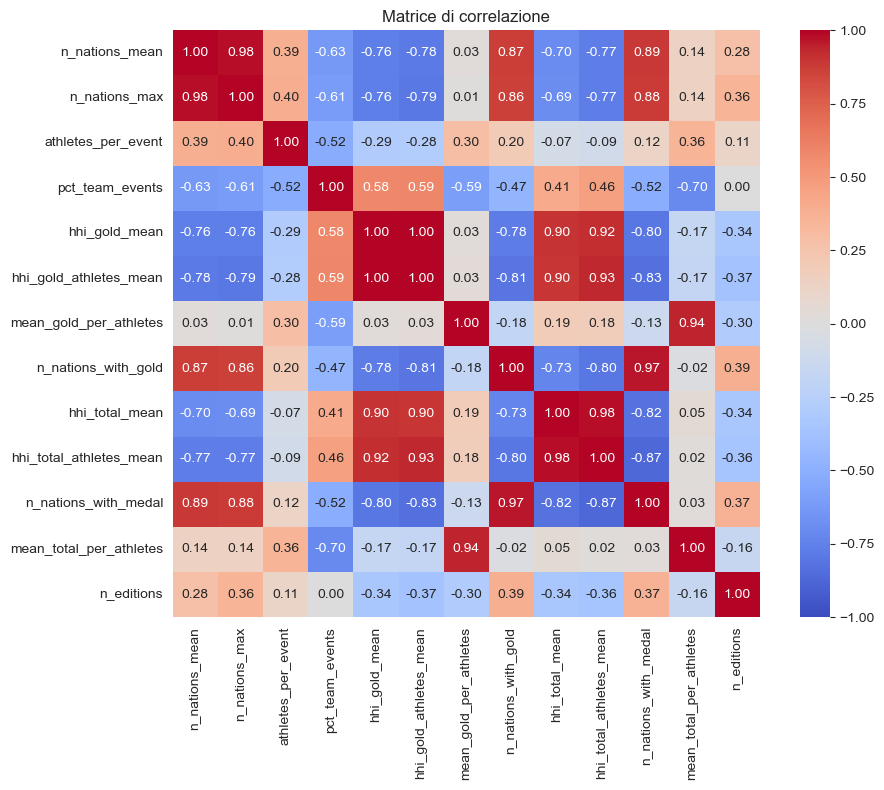

In [209]:
#Calcolo la correlazione tra le variabili numeriche per scegliere quelle da usare nel clustering
num_features = ['n_nations_mean', 'n_nations_max', 'athletes_per_event', 'pct_team_events', 'hhi_gold_mean', 'hhi_gold_athletes_mean', 'mean_gold_per_athletes', 'n_nations_with_gold', 'hhi_total_mean', 'hhi_total_athletes_mean', 'n_nations_with_medal', 'mean_total_per_athletes', 'n_editions']

corr = df_sport_profile[num_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [210]:
# In base alle correlazioni osservate, mantengo un sottoinsieme di 5 features per il clustering. Nonostante n_editions non sia correlata con nessun'altra feature, non la inserisco nel clustering perchè mi serviva soltanto per filtrare gli sport da mantenere in fase di clustering
feat_for_clust = ['n_nations_mean', 'athletes_per_event', 'hhi_gold_mean', 'mean_gold_per_athletes', 'pct_team_events']

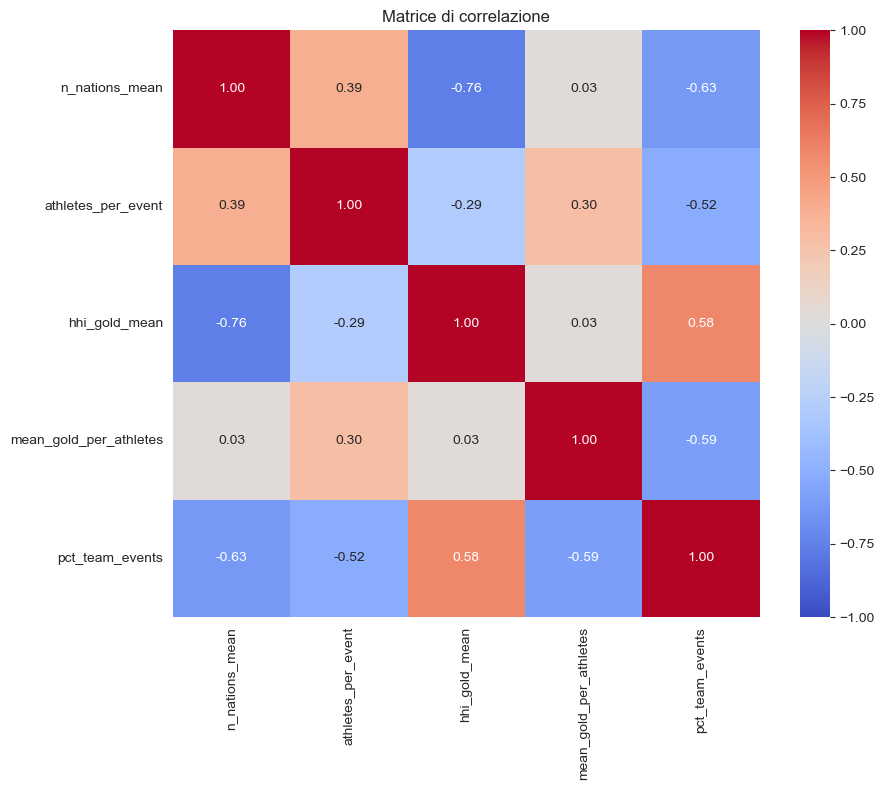

In [211]:
# Verifico nuovamente le correlazioni
corr2 = df_sport_profile[feat_for_clust].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [212]:
#Standardizzo le features per il clustering
X = df_sport_profile[feat_for_clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [213]:
# valuto il clustering con diversi k per scegliere il migliore
kmin = 2
kmax = 10

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

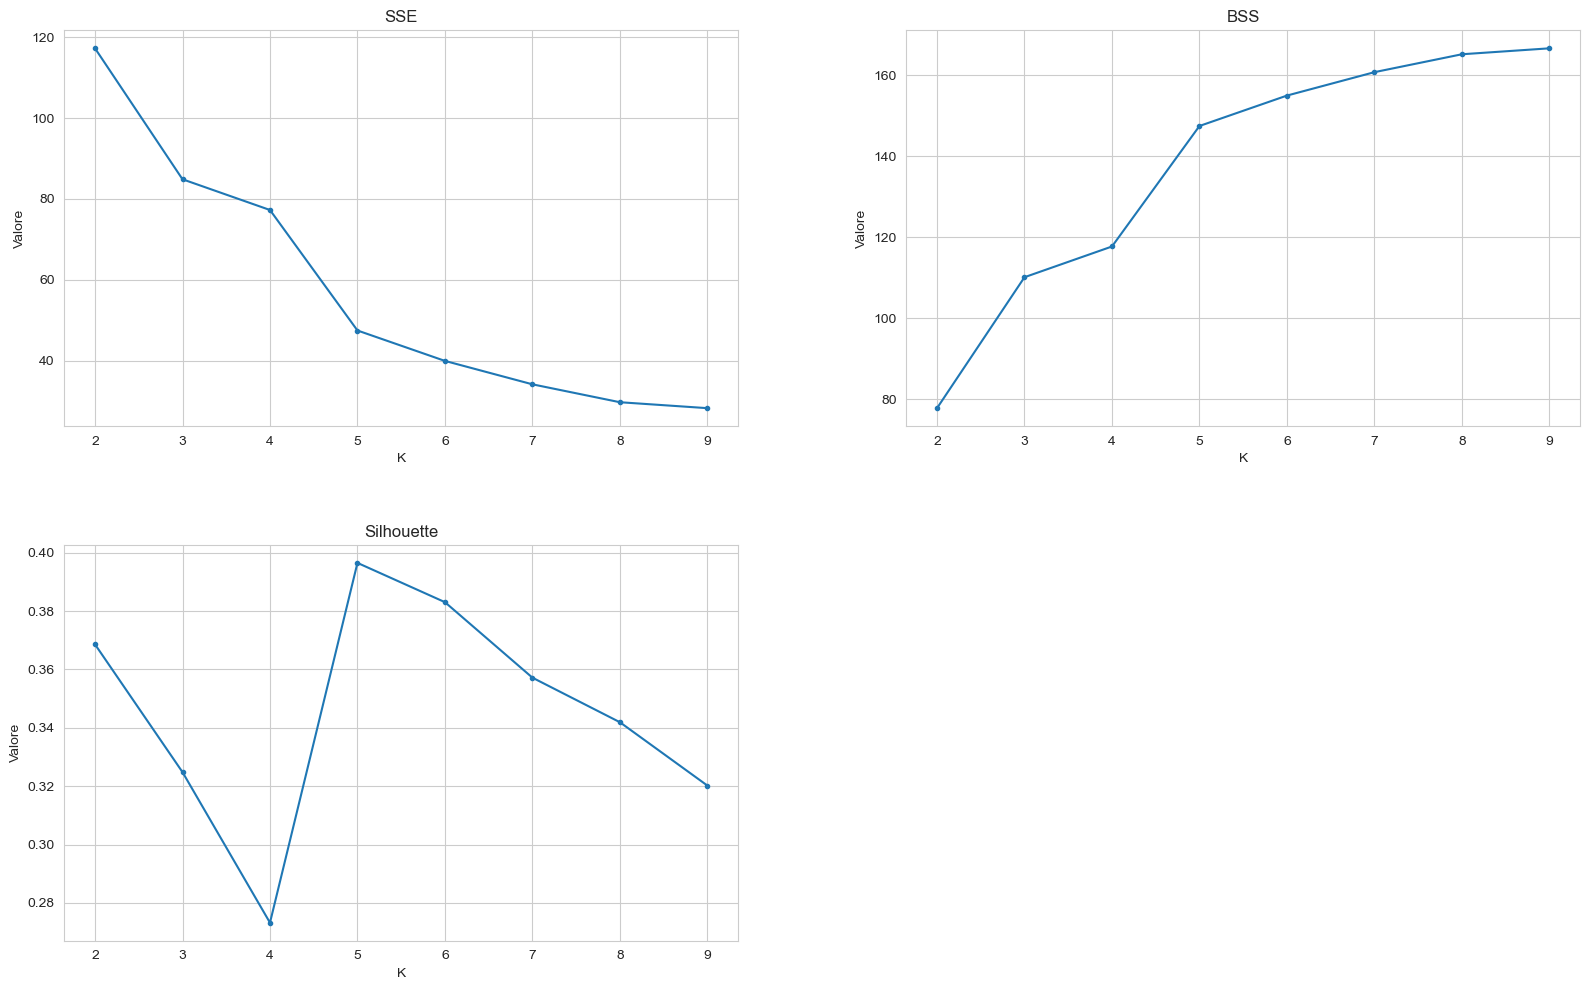

In [214]:
#plotto i risultati
metrics = ["sse", "bss", "silh"]
titles = ["SSE","BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

axes[3].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [215]:
# Scelgo k = 5 perchè su questo valore individuo il gomito a scendere nel grafico della SSE, il gomito a salire in quello della BSS e il picco in quello della silhouette
n_clust_k5 = KMeans(n_clusters=5,  random_state=42)
n_clust_k5.fit(X_scaled)
df_sport_profile['cluster_k5'] = n_clust_k5.labels_

In [216]:
#Numero di istanze in ogni cluster
labels, sizes = np.unique(n_clust_k5.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s/len(X)))

Cluster 0: 11 (0.28)
Cluster 1: 9 (0.23)
Cluster 2: 3 (0.08)
Cluster 3: 13 (0.33)
Cluster 4: 3 (0.08)


In [217]:
#Rendo uniformi i colori per i cluster nei vari grafici
cluster_colors = {
    'Cluster 0': '#4c78a8',
    'Cluster 1': '#f58518',
    'Cluster 2': '#e45756',
    'Cluster 3': '#b279a2',
    'Cluster 4': '#54a24b',
}

color_scale = alt.Scale(
    domain=list(cluster_colors.keys()),
    range=list(cluster_colors.values())
)

In [218]:
# Visualizzo i centroidi dei cluster tramite coordinate parallele
centroids = pd.DataFrame(
    n_clust_k5.cluster_centers_,
    columns=feat_for_clust
)
centroids['cluster'] = [f'Cluster {i}' for i in range(len(centroids))]

centroids_long = centroids.melt(
    id_vars='cluster',
    value_vars=feat_for_clust,
    var_name='feature',
    value_name='valore'
)

alt.Chart(centroids_long).mark_line(point=True).encode(
    x=alt.X('feature:N', sort=feat_for_clust, title=None, axis=alt.Axis(labelAngle=0)),
    y=alt.Y('valore:Q', title='Valori'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['cluster', 'feature', 'valore']
).properties(
    width=500,
    height=300,
    title='Coordinate parallele — centroidi cluster'
).interactive()

alt.Chart(...)

In [219]:
#PCA per visualizzare i cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns =['PC1', 'PC2'])
df_pca['cluster'] = ['Cluster ' + str(c) for c in df_sport_profile['cluster_k5'].values]
df_pca['sport'] = df_sport_profile['sport'].values

alt.Chart(df_pca).mark_circle(size=80, opacity=0.7).encode(
    x = alt.X('PC1:Q', title ='Prima componente principale'),
    y = alt.Y('PC2:Q', title='Seconda componente principale'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['sport', 'cluster']
).properties(
    width=500,
    height=400,
    title='PCA - Clustering sport'
).interactive()

alt.Chart(...)

In [220]:
#Visualizzo la composizione dei cluster, quindi quali sport appartengono ad ogni cluster
for k in sorted(df_sport_profile['cluster_k5'].unique()):
    sports = df_sport_profile[df_sport_profile['cluster_k5'] == k]['sport'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['Archery', 'Artistic Swimming', 'Cycling Mountain Bike', 'Diving', 'Equestrian Dressage', 'Equestrian Eventing', 'Equestrian Jumping', 'Modern Pentathlon', 'Rhythmic Gymnastics', 'Table Tennis', 'Trampolining']

Cluster 1:
['Baseball', 'Basketball', 'Beach Volleyball', 'Football', 'Handball', 'Hockey', 'Softball', 'Volleyball', 'Water Polo']

Cluster 2:
['Athletics', 'Shooting', 'Swimming']

Cluster 3:
['Badminton', 'Boxing', 'Canoe Slalom', 'Canoe Sprint', 'Cycling Track', 'Fencing', 'Judo', 'Rowing', 'Sailing', 'Taekwondo', 'Tennis', 'Weightlifting', 'Wrestling']

Cluster 4:
['Artistic Gymnastics', 'Cycling Road', 'Triathlon']


## INTERPRETAZIONE CLUSTER

- Cluster 0, il cluster degli "sport tecnici": sport con poche nazioni partecipanti, con un numero medio di atleti partecipanti per evento, con hhi alto (quindi con poche nazioni dominanti), con una media di ori per atleta alta (quindi efficienza alta perchè i Paesi che vincono ori in questo sport li vincono con pochissimi atleti partecipanti, quindi pochi specialisti che vincono però la medaglia d'oro), con un numero medio di eventi di squadra nella categoria sportiva. Gli sport appartenenti a questo cluster sono: Archery, Artistic Swimming, Cycling Mountain Bike, Diving, Equestrian Dressage, Equestrian Eventing, Equestrian Jumping, Modern Pentathlon, Rhythmic Gymnastics, Table Tennis, Trampolining.
- Cluster 1, il cluster degli "sport di squadra": sport con pochissime nazioni partecipanti e, di conseguenza, un numero di atleti più ridotto, con hhi alto (quindi con poche nazioni dominanti), con mean_gold_per_athletes basso (si considera 1 oro per l'intera squadra e non per ogni atlata appartenente alla squadra, cosa che rende basso questo rapporto), e con numero alto di eventi di squadra nella categoria sportiva. Gli sport appartenenti a questo cluster sono: Baseball, Basketball, Beach Volleyball, Football, Handball, Hockey, Softball, Volleyball, Water Polo.
- Cluster 2, il cluster dei "giganti olimpici": sport con tantissime nazioni partecipanti, con numero di atleti medio-alto, con hhi molto basso (quindi ori distribuiti tra le varie nazioni) e di conseguenza mean_gold_per_athletes medio-basso, e con percentuale di eventi di squadra nella categoria sportiva bassisimo. Gli sport appartenenti a questo cluster sono: Athletics, Shooting, Swimming.
- Cluster 3, il cluster degli "sport di media diffusione": sport con un numero medio di nazioni partecipanti e di atleti per evento, con hhi basso (quindi distribuzione degli ori bilanciata), con mean_gold_per_athletes nella media e con un numero di eventi di squadra nella media. Gli sport appartenenti a questo cluster sono: Badminton, Boxing, Canoe Slalom, Canoe Sprint, Cycling Track, Fencing, Judo, Rowing, Sailing, Taekwondo, Tennis, Weightlifting, Wrestling.
- Cluster 4, il cluster degli "sport ad alto volume di partecipanti": sport con un numero medio di nazioni partecipanti, con tantissimi atleti schierati, con hhi sugli ori medio, con un mean_gold_per_athletes medio, e con una bassa percentuale di sport di squadra. Gli sport appartenenti a questo cluster sono: Artistic Gymnastics, Cycling Road, Triathlon.

## Analisi temporale

In [221]:
#Unisco la colonna dei cluster al dataset sport_year
df_sport_year = df_sport_year.merge(
    df_sport_profile[['sport', 'cluster_k5']],
    on='sport',
    how='left'
)

In [222]:
df_sport_year

,sport,year,n_nations,n_events,athletes_per_event,pct_team_events,hhi_gold,hhi_gold_athletes,n_nations_with_gold,mean_gold_per_athletes,hhi_total,hhi_total_athletes,n_nations_with_medal,mean_total_per_athletes,cluster_k5
0,3x3 Basketball,2020,13,2,8.000000,1.0,0.500000,0.500000,2,0.250000,0.222222,0.209877,5,0.225000,NaN
1,Archery,1972,26,2,46.500000,0.0,1.000000,1.000000,1,0.333333,0.222222,0.214033,5,0.256667,0.0
2,Archery,1976,24,2,32.000000,0.0,1.000000,1.000000,1,0.500000,0.277778,0.295000,4,0.416667,0.0
3,Archery,1980,23,2,32.000000,0.0,0.500000,0.500000,2,0.250000,0.388889,0.368421,3,0.527778,0.0
4,Archery,1984,31,2,49.000000,0.0,0.500000,0.500000,2,0.166667,0.277778,0.271592,4,0.258333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,Wrestling,2008,54,18,18.666667,0.0,0.197531,0.164491,10,0.178526,0.056140,0.048945,29,0.310828,3.0
513,Wrestling,2012,63,18,18.555556,0.0,0.185596,0.176969,7,0.199117,0.067901,0.050588,28,0.319112,3.0
514,Wrestling,2016,62,18,19.000000,0.0,0.141975,0.134253,10,0.180716,0.065586,0.052154,27,0.326136,3.0
515,Wrestling,2020,57,18,15.777778,0.0,0.179012,0.157398,8,0.189883,0.062114,0.050427,26,0.340609,3.0


In [223]:
df_sport_year = df_sport_year.dropna(subset=['cluster_k5'])

In [224]:
df_sport_year['cluster_k5'] = df_sport_year['cluster_k5'].astype(int)

In [225]:
trend_k5 = df_sport_year.groupby(['cluster_k5', 'year'])[['n_nations', 'hhi_gold', 'mean_gold_per_athletes', 'athletes_per_event']].mean().reset_index()

In [226]:
trend_k5['cluster_k5'] = trend_k5['cluster_k5'].apply(lambda x: f'Cluster {x}')

In [227]:
#Plotto i grafici sull'andamento delle seguenti features nel corso del tempo: nazioni partecipanti, concentrazione ori, perdia ori per atleta, atleti per evento
metrics = {
    'n_nations': 'Nazioni partecipanti',
    'hhi_gold': 'Concentrazione ori (HHI)',
    'mean_gold_per_athletes': 'Media ori per atleta',
    'athletes_per_event': 'Atleti per evento'
}

charts = []
for col, title in metrics.items():
    chart = alt.Chart(trend_k5).mark_line(point=True).encode(
        x=alt.X('year:O', title='Anno'),
        y=alt.Y(f'{col}:Q', title=title),
        color=alt.Color('cluster_k5:N', title='Cluster', scale=color_scale),
        tooltip=['cluster_k5', 'year', alt.Tooltip(f'{col}:Q', format='.2f')]
    ).properties(
        width=350,
        height=250,
        title=title
    )
    charts.append(chart)

alt.vconcat(*[
    alt.hconcat(*charts[i:i+2]) for i in range(0, len(charts), 2)
]).properties(
    title='Evoluzione temporale cluster k=5'
)


alt.VConcatChart(...)

## Interpretazione

- Cluster 0, sport tecnici: il numero di nazioni partecipanti è basso e ha una cresicta lenta nel corso del tempo; la concentrazione degli ori è alta e ha un picco nel 1988; la media delle medaglie d'oro per atleta è sempre la più alta tra tutti i cluster; il numero di atleti per evento è medio-basso e si mantiene stabile nel corso del tempo.
- Cluster 1, sport di squadra: le nazioni sono sempre pochissime nel corso del tempo; la concentrazione degli ori è altissima negli anni più antichi e man mano scende; la media di ori per atleta è sempre bassa ed è la più bassa tra tutti i cluster (coerente con la logica di un oro unico per tutta la squadra); nonostante siano sport di squadra, il numero di atleti per evento è basso perchè sono poche le nazioni che partecipano.
- Cluster 2, giganti olimpic: le nazioni partecipanti hanno una forte crescita nel corso del tempo (si nota un calo nel 1980 a causa del boicottaggio di Mosca), i giganti olimpici sono gli sport più globalizzati; la concentrazione degli ori è bassa e scende nel corso del tempo, mostrando la "democraticità" di questi sport; la media di medaglie d'oro per atleta è bassa e stabile, conseguenza dell'alto numero di nazioni partecipanti; il numero di atleti per evento è alto e stabile.
- Cluster 3, sport di media diffusione: nel corso del tempo c'è una crescita moderata di nazioni partecipanti; la concentrazione degli ori si mantiene stabile e bassa; la media delle medaglie d'oro per atleta è invece meno stabile e presenta picchi e cali; il numero di atleti per evento è medio-basso e stabile.
- Cluster 4, sport ad alto volume di partecipanti: nel corso del tempo c'è una crescita moderata di nazioni partecipanti; la concentrazione degli ori ha un picco "anomalo" nel 1980, probabilmente a causa del boicottaggio di Mosca, quindi l'edizione olimpica in cui ha partecipato un minor numero di nazioni e quindi è plausibile ci sia stata meno "competizione" per gli ori; la media di medaglie d'oro per atleti non è stabile; il numero di atleti per evento è altissimo, con un picco nel 1972.

## I top paesi con più ori per ogni sport nel corso del tempo

In [228]:
df_macro_sport['year'] = df_macro_sport['year'].astype(int)

In [229]:
df_macro_sport

,country_noc,country,year,sport,num_athletes,gold,silver,bronze,total_medals,gold_per_athletes,tot_med_per_athletes
0,IOA,Independent Olympic Athletes,1992,Shooting,8,0,1,2,3,0.0,0.375
1,IOA,Independent Olympic Athletes,1992,Canoe Slalom,3,0,0,0,0,0.0,0.000
2,IOA,Independent Olympic Athletes,2000,Weightlifting,1,0,0,0,0,0.0,0.000
3,IOA,Independent Olympic Athletes,2000,Boxing,1,0,0,0,0,0.0,0.000
4,ISV,United States Virgin Islands,1976,Wrestling,4,0,0,0,0,0.0,0.000
...,...,...,...,...,...,...,...,...,...,...,...
18958,TOG,Togo,2008,Tennis,1,0,0,0,0,0.0,0.000
18959,TOG,Togo,2012,Athletics,2,0,0,0,0,0.0,0.000
18960,TOG,Togo,2012,Canoe Slalom,1,0,0,0,0,0.0,0.000
18961,TOG,Togo,2012,Judo,1,0,0,0,0,0.0,0.000


In [230]:
#Grafico interattivo per vedere i 5 top paesi per medaglie d'oro in ogni sport nel corso del tempo
gold_by_country = df_macro_sport[df_macro_sport['gold'] > 0][['sport', 'year', 'country', 'gold']].rename(columns={'gold': 'golds'})

sports_list = df_sport_profile['sport'].tolist()


top5_by_sport = (
    gold_by_country.groupby(['sport', 'country'])['golds']
    .sum()
    .reset_index()
    .sort_values(['sport', 'golds'], ascending=[True, False])
    .groupby('sport')
    .head(5)
)

gold_top5 = gold_by_country.merge(
    top5_by_sport[['sport', 'country']],
    on=['sport', 'country'],
    how='inner'
)

sport_dropdown = alt.binding_select(options=sports_list, name='Sport: ')
sport_select = alt.selection_point(fields=['sport'], bind=sport_dropdown, value=sports_list[0])

alt.Chart(gold_top5).mark_line(point=True).encode(
    x=alt.X('year:Q', title='Anno', axis=alt.Axis(format='d')),
    y=alt.Y('golds:Q', title='Ori vinti'),
    color=alt.Color('country:N', title='Paese'),
    tooltip=['country', 'year', 'golds']
).add_params(
    sport_select
).transform_filter(
    sport_select
).properties(
    width=600,
    height=400,
    title='Top 5 paesi per ori nel tempo'
)

alt.Chart(...)

In [231]:
#Grafico interattivo per vedere i 5 top paesi per medaglie totali in ogni sport nel corso del tempo
medals_by_country = df_macro_sport[df_macro_sport['total_medals'] > 0][['sport', 'year', 'country', 'total_medals']]

top5_by_sport_total = (
    medals_by_country.groupby(['sport', 'country'])['total_medals']
    .sum()
    .reset_index()
    .sort_values(['sport', 'total_medals'], ascending=[True, False])
    .groupby('sport')
    .head(5)
)

medals_top5 = medals_by_country.merge(
    top5_by_sport_total[['sport', 'country']],
    on=['sport', 'country'],
    how='inner'
)

sport_dropdown_total = alt.binding_select(options=sports_list, name='Sport: ')
sport_select_total = alt.selection_point(fields=['sport'], bind=sport_dropdown_total, value=sports_list[0])

y_max_total = medals_top5['total_medals'].max() * 1.1

alt.Chart(medals_top5).mark_line(point=True).encode(
    x=alt.X('year:Q', title='Anno', axis=alt.Axis(format='d')),
    y=alt.Y('total_medals:Q', title='Medaglie totali vinte'),
    color=alt.Color('country:N', title='Paese'),
    tooltip=['country', 'year', 'total_medals']
).add_params(
    sport_select_total
).transform_filter(
    sport_select_total
).properties(
    width=600,
    height=400,
    title='Top 5 paesi per medaglie totali nel tempo'
)

alt.Chart(...)

In [232]:
#Secondo grafico interattivo per vedere i 5 top paesi per medaglie d'oro in ogni sport nel corso del tempo.
heatmap_data_gold = []
for sport in sports_list:
    df_s = df_macro_sport[df_macro_sport['sport'] == sport][['country', 'year', 'gold']]
    pivot = df_s.pivot_table(index='country', columns='year', values='gold', aggfunc='sum', fill_value=0)
    totals = pivot.sum(axis=1)
    top10 = totals.nlargest(10).index
    pivot = pivot.loc[top10]

    #Creo un ranking esplicito (0 = paese con più ori, 9 = decimo)
    rank_order = {country: i for i, country in enumerate(top10)}

    pivot_long = pivot.reset_index().melt(id_vars='country', var_name='year', value_name='gold')
    pivot_long['sport'] = sport
    pivot_long['rank'] = pivot_long['country'].map(rank_order)
    heatmap_data_gold.append(pivot_long)

heatmap_gold = pd.concat(heatmap_data_gold, ignore_index=True)
heatmap_gold['year'] = heatmap_gold['year'].astype(int)

sport_dropdown_heat = alt.binding_select(options=sports_list, name='Sport: ')
sport_select_heat = alt.selection_point(fields=['sport'], bind=sport_dropdown_heat, value=sports_list[0])

alt.Chart(heatmap_gold).mark_rect().encode(
    x=alt.X('year:O', title='Anno'),
    y=alt.Y('country:N', title='Paese', sort=alt.SortField(field='rank', order='ascending')),
    color=alt.Color('gold:Q', title='Ori vinti', scale=alt.Scale(scheme='yelloworangered')),
    tooltip=['country', 'year', 'gold']
).add_params(
    sport_select_heat
).transform_filter(
    sport_select_heat
).properties(
    width=600,
    height=300,
    title='Ori per paese nel tempo'
)

alt.Chart(...)

In [233]:
#Secondo grafico interattivo per vedere i 5 top paesi per medaglie totali in ogni sport nel corso del tempo.
heatmap_data_total = []
for sport in sports_list:
    df_s2 = df_macro_sport[df_macro_sport['sport'] == sport][['country', 'year', 'total_medals']]
    pivot2 = df_s2.pivot_table(index='country', columns='year', values='total_medals', aggfunc='sum', fill_value=0)
    totals2 = pivot2.sum(axis=1)
    top10_2 = totals2.nlargest(10).index
    pivot2 = pivot2.loc[top10_2]

    #Creo un ranking esplicito (0 = paese con più medaglie, 9 = decimo)
    rank_order2 = {country: i for i, country in enumerate(top10_2)}

    pivot2_long = pivot2.reset_index().melt(id_vars='country', var_name='year', value_name='total_medals')
    pivot2_long['sport'] = sport
    pivot2_long['rank'] = pivot2_long['country'].map(rank_order2)
    heatmap_data_total.append(pivot2_long)

heatmap_total = pd.concat(heatmap_data_total, ignore_index=True)
heatmap_total['year'] = heatmap_total['year'].astype(int)

sport_dropdown_heat_total = alt.binding_select(options=sports_list, name='Sport: ')
sport_select_heat_total = alt.selection_point(fields=['sport'], bind=sport_dropdown_heat_total, value=sports_list[0])

alt.Chart(heatmap_total).mark_rect().encode(
    x=alt.X('year:O', title='Anno'),
    y=alt.Y('country:N', title='Paese', sort=alt.SortField(field='rank', order='ascending')),
    color=alt.Color('total_medals:Q', title='Medaglie totali', scale=alt.Scale(scheme='yelloworangered')),
    tooltip=['country', 'year', 'total_medals']
).add_params(
    sport_select_heat_total
).transform_filter(
    sport_select_heat_total
).properties(
    width=600,
    height=300,
    title='Medaglie totali per paese nel tempo'
)

alt.Chart(...)